![Finance Toolkit](https://github.com/JerBouma/FinanceToolkit/assets/46355364/198d47bd-e1b3-492d-acc4-5d9f02d1d009)

**The FinanceToolkit** is an open-source toolkit in which all relevant financial methods (500+) are written down in the most simplistic way allowing for complete transparency of the calculation method. This allows you to not have to rely on metrics from other providers and, given a financial statement, allow for efficient manual calculations. This leads to one uniform method of calculation being applied that is available and understood by everyone.

# Installation
To install the FinanceToolkit it simply requires the following:

```
pip install financetoolkit -U
```

From within Python use:

```python
from financetoolkit import Toolkit
```
 
To be able to get started, you need to obtain an API Key from FinancialModelingPrep. This is used to gain access to 30+ years of financial statement both annually and quarterly. Note that the Free plan is limited to 250 requests each day, 5 years of data and only features companies listed on US exchanges.

___ 

<b><div align="center">Obtain an API Key from FinancialModelingPrep <a href="https://www.jeroenbouma.com/fmp" target="_blank">here</a>.</div></b>
___

Through the link you are able to subscribe for the free plan and also premium plans at a **15% discount**. This is an affiliate link and thus supports the project at the same time. I have chosen FinancialModelingPrep as a source as I find it to be the most transparent, reliable and at an affordable price. When you notice that data is inaccurate or have any other issue related to the data, note that I simply provide the means to access this data and I am not responsible for the accuracy of the data itself. For this, use <a href="https://site.financialmodelingprep.com/contact" target="_blank">their contact form</a> or provide the data yourself.

In [1]:
from financetoolkit import Toolkit

API_KEY = "FINANCIAL_MODELING_PREP_API_KEY"

The Performance module is meant to calculate important performance metrics such as Sharpe Ratio, Sortino Ratio, Treynor Ratio, Information Ratio, Jensen's Alpha, Beta, Capital Asset Pricing Model and more.

In [2]:
# Initialize the Toolkit with company tickers
companies = Toolkit(
    ["ASML", "MSFT", "AAPL", "WMT"], api_key=API_KEY, start_date="2005-01-01"
)

The metrics found here are really about understanding how well a stock (or portfolio) is performing often as opposed to a benchmark (as defined within the Toolkit class, by default this is the S&P 500). It helps in understanding whether the stock is worth the risk and whether it is worth the investment. For example, by looking at Jensen's Alpha which compares the actual return of a stock to the expected return based on the CAPM model, you can see whether the stock is over- or underperforming.

By default, you will acquire the `yearly` or `quarterly` results (if `quarterly=True`) but you als have the option to obtain the `monthly` and `weekly` results.

In [3]:
companies.performance.get_jensens_alpha(period="quarterly")

2026-07-10 09:48:43 - financetoolkit - INFO - Obtaining treasury data for 1 ticker(s)


2026-07-10 09:48:44 - financetoolkit - INFO - Obtaining historical data for 5 ticker(s)


,ASML,MSFT,AAPL,WMT
Date,,,,
2006Q3,0.0202,-0.0163,0.0165,0.0073
2006Q4,-0.0091,0.0344,0.0352,-0.1273
2007Q1,0.0121,-0.0651,0.0987,0.004
2007Q2,0.0501,-0.0015,0.2591,-0.0321
2007Q3,0.1841,-0.0196,0.2472,-0.1074
...,...,...,...,...
2025Q3,0.1167,-0.0304,0.1527,0.0036
2025Q4,0.0962,-0.0938,0.0407,0.0335
2026Q1,0.3992,-0.1879,-0.0252,0.0855


Jensen's Alpha uses the Capital Asset Pricing Model (CAPM) to calculate whether the stock is outperforming the benchmark. This is also a separate function.

In [4]:
companies.performance.get_capital_asset_pricing_model(period="yearly")

,ASML,MSFT,AAPL,WMT
Date,,,,
2006,-0.0244,0.0117,-0.0214,-0.0106
2007,0.0327,0.0329,0.0311,0.0337
2008,-0.3803,-0.3565,-0.3523,-0.2192
2009,0.2949,0.216,0.2156,0.1011
2010,0.1669,0.1178,0.1337,0.0704
2011,-0.0089,0.0017,0.0027,0.0088
2012,0.1602,0.1483,0.1629,0.0661
2013,0.349,0.2641,0.1939,0.1644
2014,0.1107,0.1089,0.0994,0.0711


**The beauty of this class is that you can view the performance metrics on a weekly, monthly, quarterly or yearly interval.** Here, if for example the variance needs to be calculated, it intelligently calculates the variance for the days within each week, month, quarter or year. This is also the case for the standard deviation and other metrics. E.g. you can view the 12-month rolling Sharpe Ratio as follows:

<Axes: title={'center': '12-Month Rolling Sharpe Ratio'}, xlabel='Date', ylabel='Sharpe Ratio'>

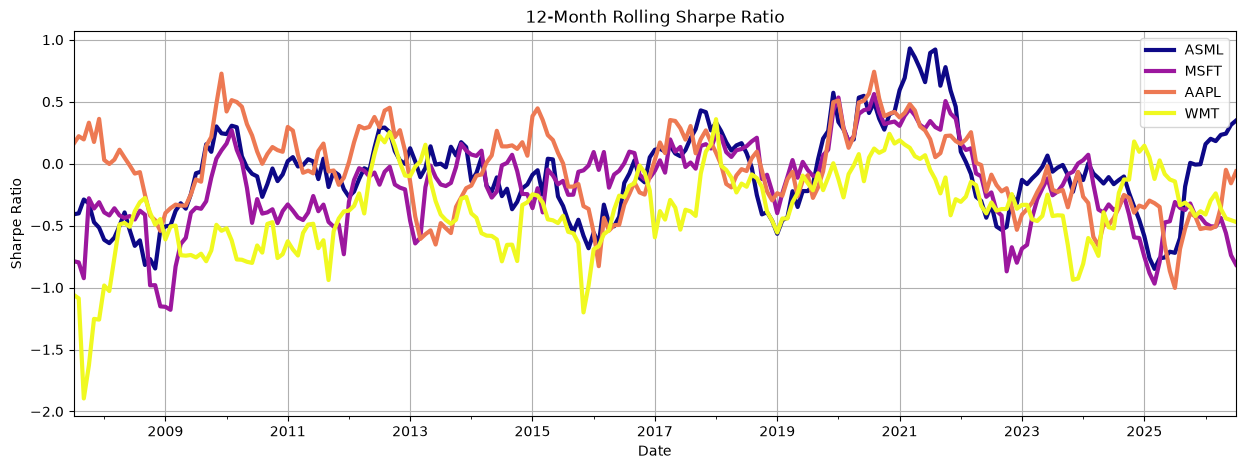

In [5]:
companies.performance.get_sharpe_ratio(period="monthly", rolling=12).plot(
    figsize=(15, 5),
    title="12-Month Rolling Sharpe Ratio",
    grid=True,
    colormap="plasma",
    lw=3,
    linestyle="-",
    ylabel="Sharpe Ratio",
    xlabel="Date",
)

Beyond Sharpe, several other risk-adjusted return ratios are available. The **Sortino Ratio** is Sharpe's downside-only cousin (penalizing only bad volatility), and the **Treynor Ratio** uses Beta instead of standard deviation as its risk measure — useful for a diversified portfolio where systematic risk is what matters.

In [6]:
display(companies.performance.get_sortino_ratio(period="monthly"))

display(companies.performance.get_treynor_ratio(period="yearly"))

,ASML,MSFT,AAPL,WMT
Date,,,,
2006-08,-3.4932,-13.8988,-2.9899,-7.7945
2006-09,-3.0855,-5.2327,-2.0999,-4.7864
2006-10,-2.8616,-5.5998,-3.2184,-3.1999
2006-11,-2.756,-7.327,-2.8013,-4.2453
2006-12,-5.372,-5.3274,-3.1596,-7.2801
...,...,...,...,...
2026-03,-1.6707,-3.0107,-3.6752,-3.4574
2026-04,-1.5892,-1.9787,-2.6654,-2.3265
2026-05,-1.5063,-2.8092,-3.3518,-2.5323


,ASML,MSFT,AAPL,WMT
Date,,,,
2006,-0.031,-0.0627,-0.0324,-0.0384
2007,0.0928,0.1615,1.11,-0.0135
2008,-0.4476,-0.5093,-0.6391,0.2641
2009,0.6496,0.5859,1.5863,-0.2662
2010,0.0652,-0.1322,0.4705,-0.0615
2011,0.0535,-0.1078,0.3059,0.1864
2012,0.1387,0.0101,0.2395,0.2995
2013,0.3555,0.4222,0.039,0.245
2014,0.1323,0.2301,0.4173,0.1289


With the various already prepared period datasets, it also becomes possible to calculate Factor Exposures via the Fama and French 5 Factor Model over a lengthy period. This performs a Linear Regression on each stock for each period and determines the regression parameters. With this you can determine how the stock returns move according to different anomalies in the market. These factors are:

- **Market Risk Premium (Mkt-RF):** Represents the additional return that investors expect to earn for taking on the risk of investing in the overall market as opposed to a risk-free asset. This relates to CAPM's Beta but is a more generalized approach in which CAPM calculates based on a benchmark of your choosing.
- **Size Premium (SMB):** Reflects the historical excess return of small-cap stocks over large-cap stocks.
- **Value Premium (HML):** Captures the historical excess return of value stocks over growth stocks.
- **Profitability (RMW):** Measures the historical excess return of high profitability stocks over low profitability stocks.
- **Investment (CMA):** Quantifies the historical excess return of low investment stocks over high investment stocks.

It is possible to do a Simple Linear Regression for each factor and a Multi Linear Regression for all factors with the dependent variable being the stock returns. The latter is the default.

In [10]:
fama_and_french = companies.performance.get_fama_and_french_model(
    period="yearly", method="simple"
)

# Show the Fama and French 5 Factor Model Results
fama_and_french

2026-07-10 09:48:49 - financetoolkit - INFO - Calculating Individual Factor Exposures


ASML                                                        \
        Mkt-RF                                                         
     Intercept   Slope R Squared P Value Standard Error Factor Value   
2006       NaN     NaN       NaN     NaN            NaN        -0.51   
2007    0.4497  25.009    0.2422     0.0         2.8037        -0.66   
2008    0.2939  49.932    0.5287     0.0         2.9759          1.7   
2009    -0.027 48.4394    0.6234     0.0          2.381        -1.01   
2010     0.043 38.5066    0.5331     0.0         2.2793         -0.1   
2011   -0.0155 42.6604    0.5426     0.0          2.477        -0.41   
2012     0.048 16.8011    0.1981     0.0         2.1462         1.71   
2013    0.0786 27.0552    0.3236     0.0          2.474         0.43   
2014    0.0336 19.1875    0.1805     0.0         2.5856        -0.93   
2015    0.0236 29.6531    0.3092     0.0         2.8034        -0.92   
2016     0.018  33.021    0.4161     0.0         2.4741        -0.52   
2017    0.0501 15.2367    0.2091     0.0         1.8777        -0.57   
2018     0.335 35.0332    0.5195     0.0         2.1353          0.9   
2019    0.3409   32.86    0.4724     0.0         2.1962         0.28   
2020    0.1072 53.7295    0.5932     0.0         2.8084          0.4   
2021     0.033 24.9835    0.4571     0.0         1.7222        -0.31   
2022    0.1633 40.2243    0.6972     0.0           1.68        -0.22   
2023    0.6235 29.4241    0.4451     0.0         2.0863        -0.43   
2024    0.4251 17.7225    0.3638     0.0         1.4824        -0.46   
2025    0.6465 32.9224    0.4634     0.0         2.2498        -0.76   
2026    0.2796 20.1552    0.4793     0.0         2.1007         0.19   

                                            ...            WMT               \
                     SMB                    ...            RMW                
     Residuals Intercept   Slope R Squared  ... Standard Error Factor Value   
2006       NaN       NaN     NaN       NaN  ...            NaN         -0.1   
2007   16.1855    0.0114  2.4185    0.0126  ...         1.0424        -0.29   
2008  -85.6008    0.0024 -1.9798    0.0061  ...         1.7331        -0.55   
2009    49.837   -0.0034  11.967    0.2086  ...         2.0143        -0.45   
2010    3.9324    0.0414   9.864    0.1388  ...         2.5114        -0.14   
2011   17.5962   -0.0216 12.4639    0.2556  ...         2.6936        -0.03   
2012  -28.5915    0.0001  1.2314     0.004  ...         1.8056          0.1   
2013  -11.2571     0.015  6.5195     0.063  ...         2.0705        -0.06   
2014   17.9616   -0.0311  6.4397     0.039  ...         2.3986        -0.11   
2015   27.0805   -0.0225  0.3855    0.0002  ...         1.4107        -0.12   
2016   17.4168    0.0246  8.3845    0.0648  ...         2.0376        -0.12   
2017     9.184     -0.03  6.0577    0.0308  ...         1.6015         0.16   
2018  -31.9696   -0.0238 -0.2583    0.0001  ...         1.5572        -0.09   
2019     -8.64    0.0022  2.8128    0.0095  ...         2.2168        -0.12   
2020   -20.951    0.0227  7.6527    0.0488  ...           1.77         0.56   
2021    8.3443   -0.0078  4.0826    0.0124  ...         4.4568         0.35   
2022    8.3723    0.0145  2.8389    0.0268  ...         3.0015        -0.54   
2023   12.4141    0.0742  4.8006    0.0169  ...         3.3718         0.67   
2024    7.6429   -0.0488 -0.4312    0.0002  ...         2.8233         0.33   
2025   24.9181    0.0156  2.5496    0.0098  ...         2.4428        -0.07   
2026   -3.4227     0.062  3.8079     0.047  ...         4.1998        -0.66   

                                                                   \
                     CMA                                            
     Residuals Intercept   Slope R Squared P Value Standard Error   
2006       NaN       NaN     NaN       NaN     NaN            NaN   
2007    0.6173   -0.0457 -0.9097    0.0026  0.4228         1.1332   
2008   -1.1206    0.0088 -1.1258    0.0

With these calculated, it is possible to plot the R-squared over time to show the explanatory power of each factor for each stock.

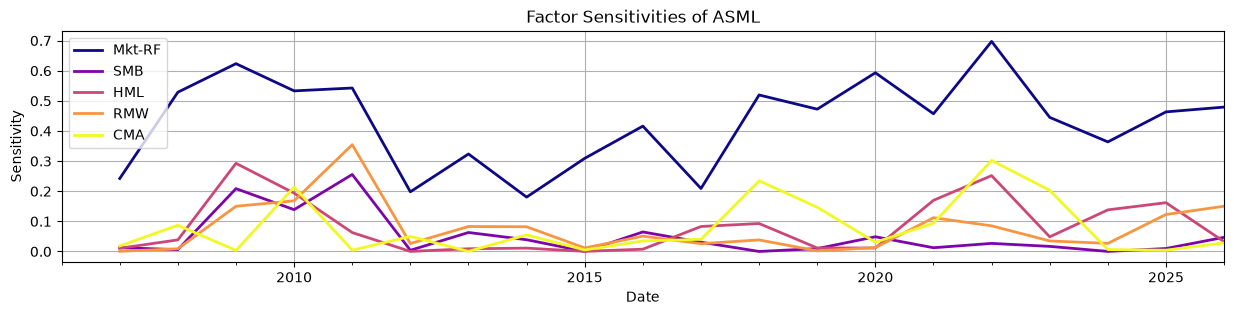

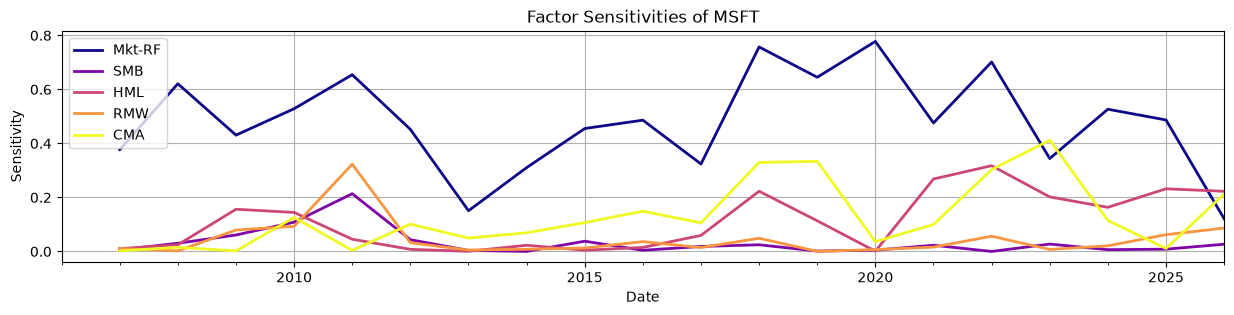

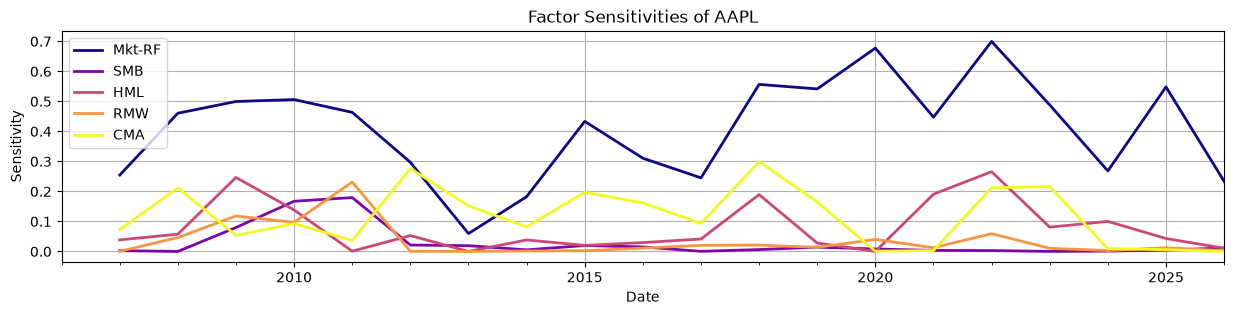

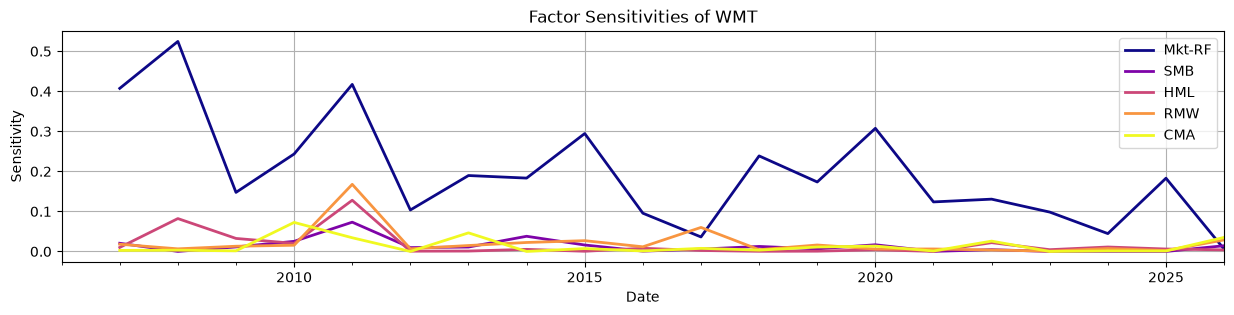

In [11]:
for ticker in companies._tickers:
    fama_and_french[ticker].xs("R Squared", level=1, axis=1).plot(
        figsize=(15, 3),
        title=f"Factor Sensitivities of {ticker}",
        grid=True,
        colormap="plasma",
        lw=2,
        linestyle="-",
        ylabel="Sensitivity",
        xlabel="Date",
    )

The correlations between factors and factors and asset returns can also be shown with `performance.get_factor_correlations` and `performance.get_factor_asset_correlations` respectively.

In [12]:
companies.performance.get_factor_asset_correlations(period="quarterly")

2026-07-10 09:49:36 - financetoolkit - INFO - Calculating Factor Asset Correlations


ASML                                  MSFT                          \
       Mkt-RF    SMB     HML     RMW     CMA Mkt-RF     SMB     HML     RMW   
2006Q3 0.4912 0.5009 -0.2635 -0.2945 -0.0063 0.3737  0.0488 -0.3079 -0.0794   
2006Q4 0.5654 0.5013 -0.3533 -0.0696 -0.2903 0.4818  0.2179 -0.2067  0.0393   
2007Q1 0.5177 0.1482 -0.1686  0.0709 -0.3909 0.7176  0.2062 -0.2134   0.254   
2007Q2 0.4359 0.2378  0.0302 -0.0408 -0.0761 0.6285 -0.0189 -0.2193  0.4082   
2007Q3 0.6373 0.0374  -0.055  0.0868   0.065 0.7912 -0.1333 -0.0656  0.2667   
...       ...    ...     ...     ...     ...    ...     ...     ...     ...   
2025Q2 0.8823  0.059 -0.6094 -0.3751  0.4812 0.8315 -0.0413 -0.6097  -0.223   
2025Q3 0.3372 0.1795 -0.1389  -0.141 -0.0907 0.4326 -0.1969 -0.3528 -0.0023   
2025Q4 0.6378 0.0154 -0.3473 -0.4105 -0.3661 0.4982 -0.1597 -0.4114 -0.2889   
2026Q1 0.7053 0.2034 -0.2763 -0.4075 -0.2952 0.3987 -0.1247 -0.4888 -0.3691   
2026Q2 0.7619 0.2418 -0.0346 -0.3821  0.0244 0.1551 -0.1817 -0.3972 -0.0879   

                 AAPL                                     WMT                  \
           CMA Mkt-RF     SMB     HML     RMW     CMA  Mkt-RF     SMB     HML   
2006Q3  0.3209 0.3105  0.2675 -0.0863  0.0253 -0.4294  0.5772  0.3213 -0.3833   
2006Q4  0.1048 0.3899  0.2379  -0.416  0.1051 -0.3928  0.4728  0.0881  -0.206   
2007Q1  -0.058 0.4467  0.2547 -0.3916 -0.1689 -0.1041   0.627  0.2018 -0.0854   
2007Q2  0.2137 0.2383  0.2133  -0.152  0.1263 -0.5162  0.4632  0.1206  -0.001   
2007Q3  0.0571 0.5005 -0.1829 -0.0002  0.2555 -0.0703  0.7933  0.0675  0.1167   
...        ...    ...     ...     ...     ...     ...     ...     ...     ...   
2025Q2  0.2277 0.9059  0.0115 -0.5264 -0.2819  0.3649  0.7756 -0.1566 -0.5015   
2025Q3 -0.5498 0.4239   0.129 -0.0898  0.1668  0.0312  0.0727  -0.217 -0.1177   
2025Q4 -0.5193 0.5772  0.2233  0.0237 -0.2728 -0.0466 -0.1702  0.2343  0.3378   
2026Q1 -0.5002 0.4689   0.065 -0.0613  0.0114 -0.0014  0.0527  0.1653  0.0262   
2026Q2 -0.3257 0.4628  0.2562 -0.1319 -0.0991  0.0686  0.2177   0.029  0.0652   

                        
           RMW     CMA  
2006Q3  -0.085  0.2988  
2006Q4  0.0035 -0.0542  
2007Q1     0.0  0.0448  
2007Q2  0.3002 -0.1215  
2007Q3  0.3446 -0.0466  
...        ...     ...  
2025Q2 -0.2554  0.1976  
2025Q3  0.1948 -0.0928  
2025Q4  0.1233  0.2392  
2026Q1  0.0387  0.2245  
2026Q2  0.2966  0.0857  

[80 rows x 20 columns]

Furthermore, given the fact that the package collects data from multiple sources, it is also possible to collect the data of those individual functions instead of via the `Toolkit` class. As an example, obtaining the dataset from Fama and French as also found here: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

In [13]:
from financetoolkit.performance import performance_model

performance_model.obtain_fama_and_french_dataset()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-01,-0.67,0.0,-0.34,-0.01,0.16,0.01
1963-07-02,0.79,-0.26,0.26,-0.07,-0.2,0.01
1963-07-03,0.63,-0.17,-0.09,0.18,-0.34,0.01
1963-07-05,0.4,0.08,-0.27,0.09,-0.34,0.01
1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01
...,...,...,...,...,...,...
2026-05-22,0.44,0.14,0.19,-0.39,0.58,0.02
2026-05-26,0.65,0.84,0.26,-1.32,-0.38,0.02
2026-05-27,0.02,0.37,-0.35,0.07,-0.18,0.02
